In [553]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [554]:
# Load the rental dataset
df = pd.read_csv("mumbai_rent.csv")
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (200, 32)

First 5 rows:


,Property_Type,Locality,Locality_Tier,Area_sqft,Bedrooms,Bathrooms,Furnishing,Floor_Number,Total_Floors,Building_Age,...,Modular_Kitchen,WiFi,Sharing_Type,Food_Included,Attached_Bath,Rent_INR,Area_Type,Tenant_Preferred,Amenities,House_Type
0,Flat,Andheri West,Mid,718,2,2,Semi,5,24,6,...,1,0,NaN,0,1,51418,Carpet Area,Bachelor,Gas Pipeline;Modular Kitchen;CCTV;Mattress;Lif...,House
1,Flat,Thane,Budget,948,2,2,Semi,6,15,10,...,1,1,NaN,0,1,49978,Built-up Area,Family,Refrigerator;Washing Machine;Wardrobe;Power Ba...,House
2,PG,Andheri West,Mid,151,0,1,Unfurnished,17,19,2,...,1,1,Single,0,1,15957,Carpet Area,Family,TV;Bed;Swimming Pool;Lift;Refrigerator,House
3,PG,Mira Road,Budget,172,0,1,Semi,18,23,13,...,1,1,Single,1,1,14994,Carpet Area,Any,Refrigerator;Intercom;Wardrobe;Bed;TV;Power Ba...,House
4,Flat,Navi Mumbai,Budget,778,1,1,Unfurnished,25,27,10,...,0,1,NaN,0,1,23073,Super Area,Bachelor,Security;Balcony;TV;Wi-Fi;CCTV;Wardrobe;Air Co...,House


In [555]:
# Check data types, missing values, and basic statistics
print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)
df.info()
print("\n" + "=" * 60)
print("STATISTICAL SUMMARY")
print("=" * 60)
print(df.describe())
print("\n" + "=" * 60)
print("MISSING VALUES")
print("=" * 60)
print(df.isnull().sum())

DATASET INFORMATION
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 32 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Property_Type           200 non-null    str    
 1   Locality                200 non-null    str    
 2   Locality_Tier           200 non-null    str    
 3   Area_sqft               200 non-null    int64  
 4   Bedrooms                200 non-null    int64  
 5   Bathrooms               200 non-null    int64  
 6   Furnishing              200 non-null    str    
 7   Floor_Number            200 non-null    int64  
 8   Total_Floors            200 non-null    int64  
 9   Building_Age            200 non-null    int64  
 10  Distance_to_Station_km  200 non-null    float64
 11  Distance_to_Metro_km    200 non-null    float64
 12  Distance_to_IT_Park_km  200 non-null    float64
 13  AC                      200 non-null    int64  
 14  Lift                    200 non-n

In [556]:
# Remove duplicate rows
initial_rows = len(df)
df.drop_duplicates(inplace=True)
print(f"Removed {initial_rows - len(df)} duplicate rows")

Removed 0 duplicate rows


In [557]:
# Convert data types for consistency
df["Bedrooms"] = df["Bedrooms"].astype(int)
df["Bathrooms"] = df["Bathrooms"].astype(int)
df["Area_sqft"] = df["Area_sqft"].astype(float)
df["Rent_INR"] = df["Rent_INR"].astype(float)

print("Data types converted successfully")

Data types converted successfully


In [558]:
# Standardize categorical text values (strip whitespace and title case)
df["Furnishing"] = df["Furnishing"].str.strip().str.title()
df["Tenant_Preferred"] = df["Tenant_Preferred"].str.strip().str.title()

print("Categorical columns standardized")

Categorical columns standardized


In [559]:
# Remove outliers using IQR method
q1 = df["Rent_INR"].quantile(0.25)
q3 = df["Rent_INR"].quantile(0.75)
iqr = q3 - q1

before_outlier = len(df)
df = df[(df["Rent_INR"] >= q1 - 1.5*iqr) & (df["Rent_INR"] <= q3 + 1.5*iqr)]
print(f"Removed {before_outlier - len(df)} outlier records")

Removed 10 outlier records


In [560]:
# Handle missing values
# Numeric columns → fill with median
num_cols = df.select_dtypes(include=['int64','float64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Categorical columns → fill with mode
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("Missing values handled successfully")

Missing values handled successfully


C:\Users\ASUS\AppData\Local\Temp\ipykernel_24208\4252054224.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns
C:\Users\ASUS\AppData\Local\Temp\ipykernel_24208\4252054224.py:9: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'd

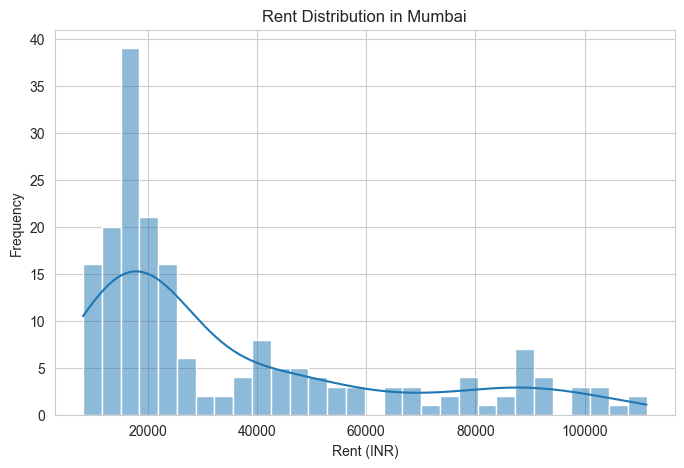

In [561]:
# Rent distribution
plt.figure(figsize=(8,5))
sns.histplot(df["Rent_INR"], bins=30, kde=True)
plt.title("Rent Distribution in Mumbai")
plt.xlabel("Rent (INR)")
plt.ylabel("Frequency")
plt.show()

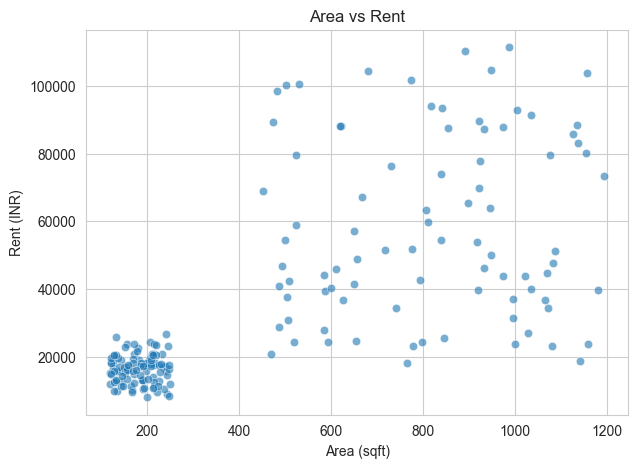

In [562]:
# Area vs Rent correlation
plt.figure(figsize=(7,5))
sns.scatterplot(x="Area_sqft", y="Rent_INR", data=df, alpha=0.6)
plt.title("Area vs Rent")
plt.xlabel("Area (sqft)")
plt.ylabel("Rent (INR)")
plt.show()

C:\Users\ASUS\AppData\Roaming\Python\Python312\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


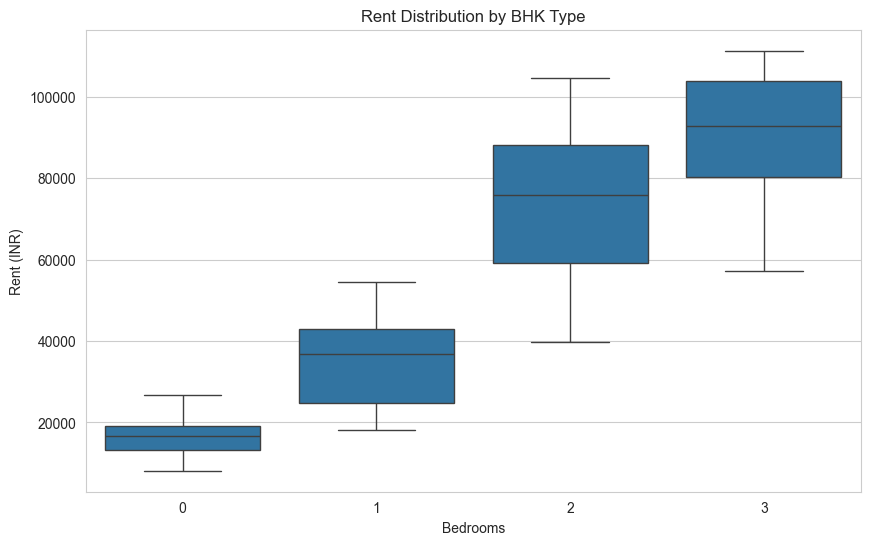

In [563]:
# Rent variation by BHK (bedrooms)
sns.boxplot(x="Bedrooms", y="Rent_INR", data=df)
plt.title("Rent Distribution by BHK Type")
plt.xlabel("Bedrooms")
plt.ylabel("Rent (INR)")
plt.show()

C:\Users\ASUS\AppData\Roaming\Python\Python312\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


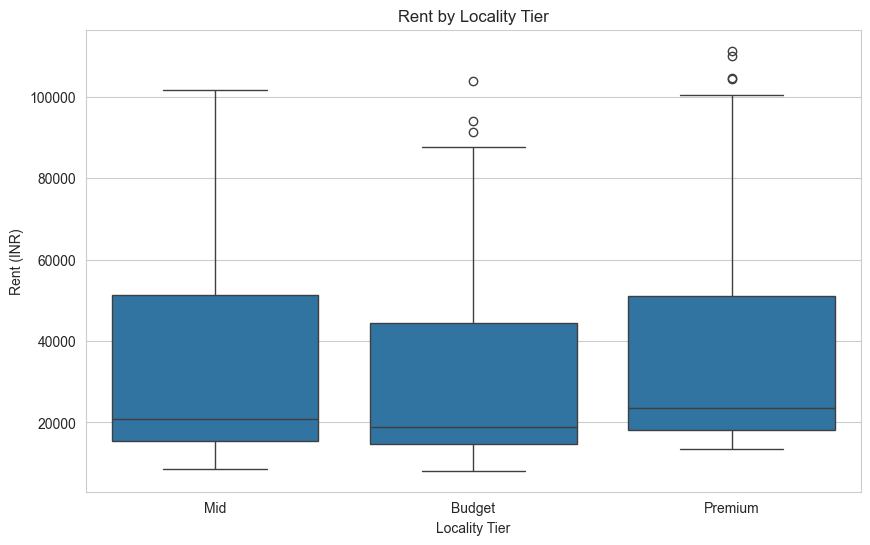

In [564]:
# Rent variation by Locality Tier
sns.boxplot(x="Locality_Tier", y="Rent_INR", data=df)
plt.title("Rent by Locality Tier")
plt.xlabel("Locality Tier")
plt.ylabel("Rent (INR)")
plt.show()

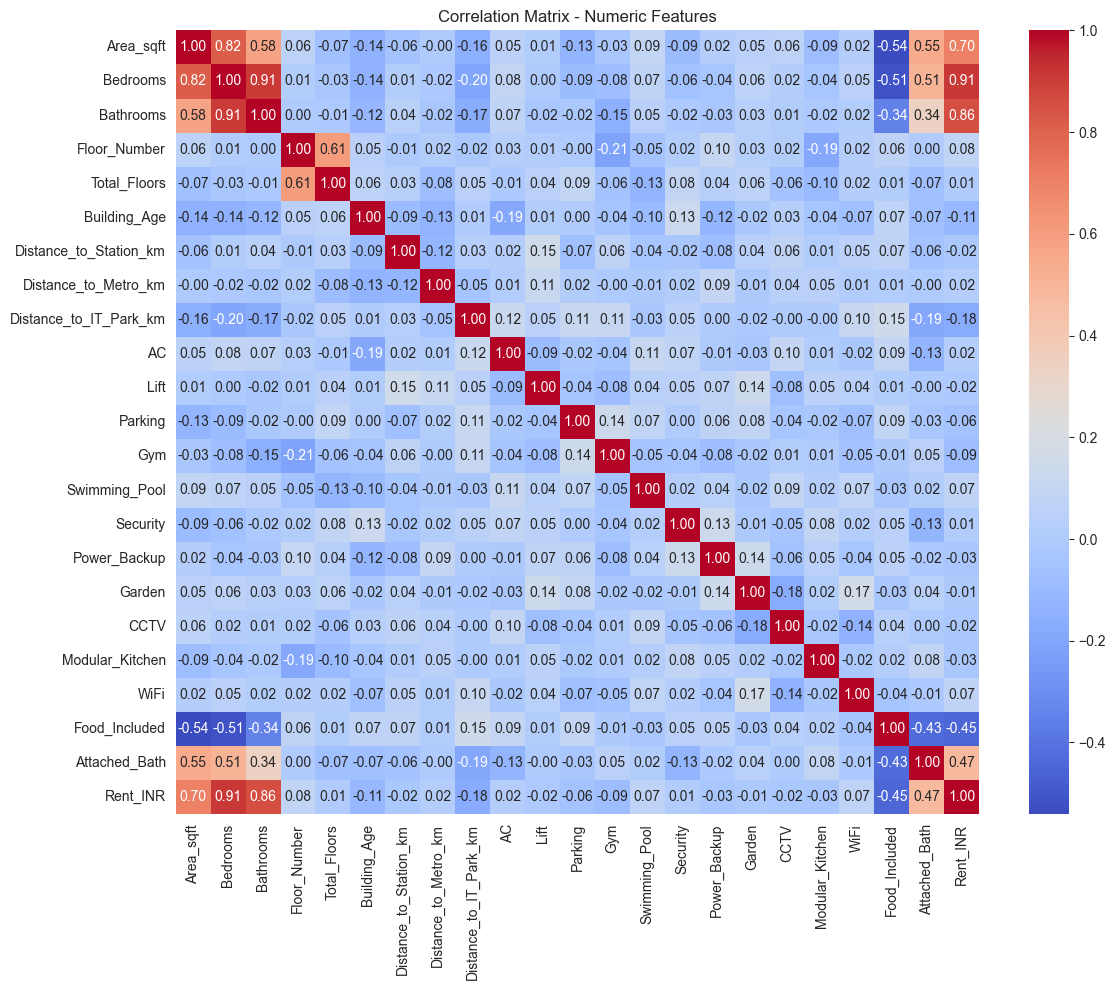

In [565]:
# Correlation heatmap
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", annot=True, fmt='.2f')
plt.title("Correlation Matrix - Numeric Features")
plt.tight_layout()
plt.show()

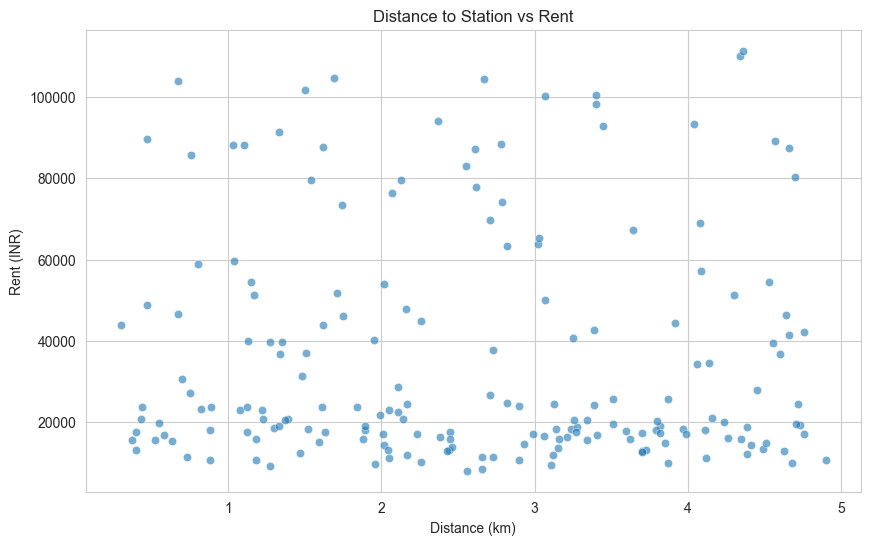

In [566]:
# Distance to Station vs Rent
sns.scatterplot(x="Distance_to_Station_km", y="Rent_INR", data=df, alpha=0.6)
plt.title("Distance to Station vs Rent")
plt.xlabel("Distance (km)")
plt.ylabel("Rent (INR)")
plt.show()

In [567]:
# Location Score: Convert tier to numeric
df["Location_Score"] = df["Locality_Tier"].map({
    "Budget": 1,
    "Mid": 2,
    "Premium": 3
})

# Transport Score: Inverse distance to station (closer = higher score)
df["Transport_Score"] = 1 / (df["Distance_to_Station_km"] + 0.1)

# IT Proximity: Inverse distance to IT park
df["IT_Proximity_Score"] = 1 / (df["Distance_to_IT_Park_km"] + 0.1)

# Space Per Person: Area efficiency metric
df["Space_Per_Person"] = df["Area_sqft"] / (df["Bedrooms"] + 1)

# Furnishing Level: Convert to numeric scale
df["Furnishing_Level"] = df["Furnishing"].map({
    "Unfurnished": 0,
    "Semi": 1,
    "Furnished": 2
})

# Total Amenities Count
amenity_cols = [
    "AC", "Lift", "Parking", "Gym", "Swimming_Pool", "Security",
    "Power_Backup", "Garden", "CCTV", "Modular_Kitchen", "WiFi"
]
df["Total_Amenities"] = df[amenity_cols].sum(axis=1)

# Luxury Score: Weighted combination of premium amenities
df["Luxury_Score"] = (
    df["Swimming_Pool"] * 3 +
    df["Gym"] * 2 +
    df["AC"] * 2 +
    df["Modular_Kitchen"] * 2 +
    df["Garden"] * 1
)

# Building Quality: Age and size indicator
df["Building_Quality"] = df["Total_Floors"] / (df["Building_Age"] + 1)

print("Feature engineering completed")

Feature engineering completed


In [568]:
# Handle remaining Yes/No columns
yes_no_cols = [
    "AC", "Lift", "Parking", "Gym", "Swimming_Pool", "Security",
    "Power_Backup", "Garden", "CCTV", "Modular_Kitchen", "WiFi"
]

for col in yes_no_cols:
    if col in df.columns:
        df[col] = df[col].map({"Yes": 1, "No": 0}).fillna(df[col])

# Convert boolean columns to integers
bool_cols = df.select_dtypes(include=['bool']).columns
df[bool_cols] = df[bool_cols].astype(int)

# One-hot encode all categorical columns at once
df = pd.get_dummies(df, columns=["Locality", "Locality_Tier", "Furnishing"], drop_first=True)

# Select only numeric features and target
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df = df[numeric_cols]

print(f"Selected {len(numeric_cols)-1} features for modeling")
print(f"Encoding completed. Final shape: {df.shape}")
print(f"Features: {df.columns.tolist()}")


Selected 30 features for modeling
Encoding completed. Final shape: (190, 31)
Features: ['Area_sqft', 'Bedrooms', 'Bathrooms', 'Floor_Number', 'Total_Floors', 'Building_Age', 'Distance_to_Station_km', 'Distance_to_Metro_km', 'Distance_to_IT_Park_km', 'AC', 'Lift', 'Parking', 'Gym', 'Swimming_Pool', 'Security', 'Power_Backup', 'Garden', 'CCTV', 'Modular_Kitchen', 'WiFi', 'Food_Included', 'Attached_Bath', 'Rent_INR', 'Location_Score', 'Transport_Score', 'IT_Proximity_Score', 'Space_Per_Person', 'Furnishing_Level', 'Total_Amenities', 'Luxury_Score', 'Building_Quality']


In [569]:
# Prepare features and target
X = df.drop("Rent_INR", axis=1)
y = df["Rent_INR"]

# Split data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

# Define regularized Random Forest model to prevent overfitting
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

# Train the model
model.fit(X_train, y_train)
print("Model training completed")

# Make predictions on test set
y_test_pred = model.predict(X_test)
y_train_pred = model.predict(X_train)

# Calculate metrics
print("\n" + "=" * 60)
print("MODEL PERFORMANCE METRICS")
print("=" * 60)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print(f"Training R² Score: {train_r2:.4f}")
print(f"Testing R² Score: {test_r2:.4f}")
print(f"Mean Absolute Error (MAE): ₹{test_mae:.2f}")
print(f"Root Mean Squared Error (RMSE): ₹{test_rmse:.2f}")

# Cross-validation for better generalization estimate
cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
print(f"\n5-Fold Cross-Validation R² Scores: {cv_scores}")
print(f"Mean CV R²: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

Training set size: 152
Testing set size: 38
Model training completed

MODEL PERFORMANCE METRICS
Training R² Score: 0.8740
Testing R² Score: 0.8982
Mean Absolute Error (MAE): ₹6099.21
Root Mean Squared Error (RMSE): ₹8131.26

5-Fold Cross-Validation R² Scores: [0.81163647 0.76098888 0.7681148  0.78685962 0.68256066]
Mean CV R²: 0.7620 (+/- 0.0434)


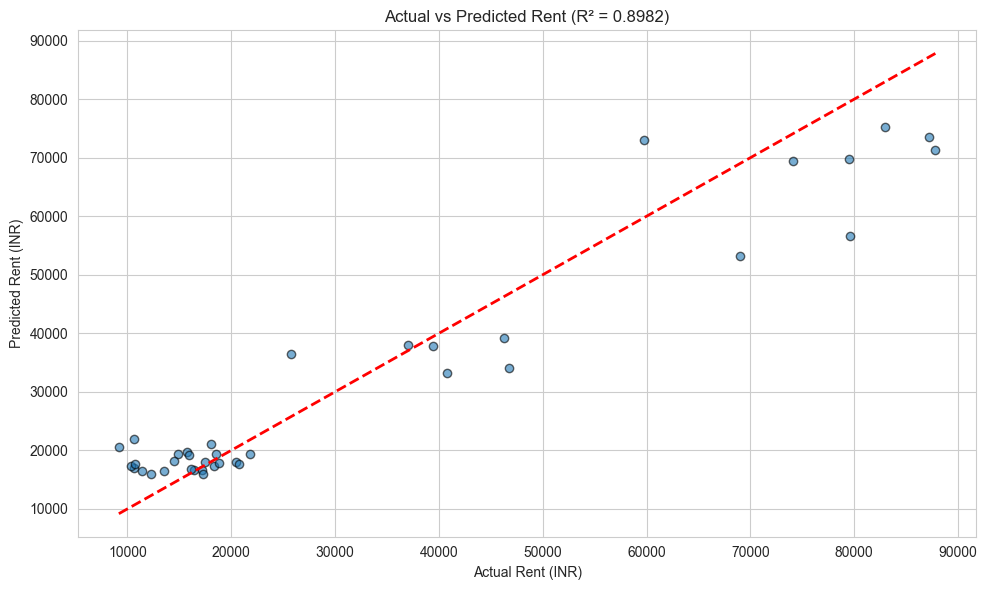

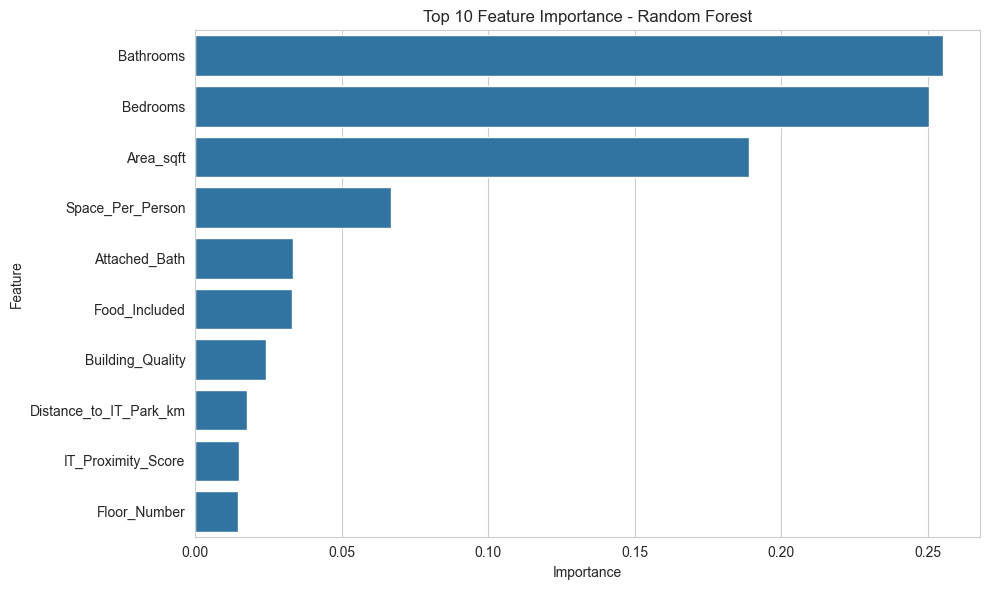

In [570]:
# Visualize actual vs predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_test_pred, alpha=0.6, edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Rent (INR)")
plt.ylabel("Predicted Rent (INR)")
plt.title(f"Actual vs Predicted Rent (R² = {test_r2:.4f})")
plt.tight_layout()
plt.show()

# Feature importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance.head(10), x='Importance', y='Feature')
plt.title("Top 10 Feature Importance - Random Forest")
plt.tight_layout()
plt.show()

In [571]:
def predict_rent(locality, area, bedrooms,
                 dist_station, dist_metro, dist_it,
                 locality_tier, furnishing, house_type):
    """
    Predict rental price for a property in Mumbai.
    
    Parameters:
    -----------
    locality : str
        Locality name (e.g., 'Andheri', 'Bandra')
    area : float
        Property area in sqft
    bedrooms : int
        Number of bedrooms
    dist_station : float
        Distance to nearest railway station (km)
    dist_metro : float
        Distance to nearest metro station (km)
    dist_it : float
        Distance to IT park (km)
    locality_tier : str
        Locality tier ('Budget', 'Mid', 'Premium')
    furnishing : str
        Furnishing type ('Unfurnished', 'Semi', 'Furnished')
    house_type : str
        Property type ('PG', 'Flat', 'House')
    
    Returns:
    --------
    float
        Predicted monthly rent in INR
    """
    
    # Initialize input data with numeric features
    input_data = {
        "Area_sqft": area,
        "Bedrooms": bedrooms,
        "Distance_to_Station_km": dist_station,
        "Distance_to_Metro_km": dist_metro,
        "Distance_to_IT_Park_km": dist_it
    }

    # Encode Locality Tier
    input_data["Locality_Tier_Mid"] = 1 if locality_tier == "Mid" else 0
    input_data["Locality_Tier_Premium"] = 1 if locality_tier == "Premium" else 0

    # Encode Furnishing Type
    input_data["Furnishing_Semi"] = 1 if furnishing == "Semi" else 0
    input_data["Furnishing_Unfurnished"] = 1 if furnishing == "Unfurnished" else 0

    # Encode House Type
    input_data["House_Type_Flat"] = 1 if house_type == "Flat" else 0
    input_data["House_Type_House"] = 1 if house_type == "House" else 0
    # PG is reference (0, 0)

    # One-hot encode Locality
    for col in X.columns:
        if col.startswith("Locality_"):
            input_data[col] = 1 if col == f"Locality_{locality}" else 0

    # Ensure all required columns exist
    for col in X.columns:
        if col not in input_data:
            input_data[col] = 0

    # Create DataFrame and make prediction
    input_df = pd.DataFrame([input_data])[X.columns]
    prediction = model.predict(input_df)[0]
    
    return prediction

In [572]:
# Example: Predict rent for a 2BHK flat in premium locality
prediction = predict_rent(
    locality="Andheri",
    area=1200,
    bedrooms=2,
    dist_station=0.5,
    dist_metro=1.2,
    dist_it=2.0,
    locality_tier="Premium",
    furnishing="Furnished",
    house_type="Flat"
)

print("=" * 60)
print("RENT PREDICTION RESULT")
print("=" * 60)
print(f"Locality: Andheri")
print(f"Area: {1200} sqft")
print(f"Bedrooms: 2")
print(f"Locality Tier: Premium")
print(f"Furnishing Type: Furnished")
print(f"Predicted Monthly Rent: ₹{round(prediction, 2):,}")
print("=" * 60)

# Additional examples
print("\nTesting additional predictions...\n")

examples = [
    {
        "name": "Budget 1BHK, Unfurnished",
        "locality": "Borivali",
        "area": 600,
        "bedrooms": 1,
        "dist_station": 1.0,
        "dist_metro": 2.0,
        "dist_it": 5.0,
        "locality_tier": "Budget",
        "furnishing": "Unfurnished",
        "house_type": "Flat"
    },
    {
        "name": "Mid-range 3BHK House",
        "locality": "Thane",
        "area": 1800,
        "bedrooms": 3,
        "dist_station": 0.2,
        "dist_metro": 3.0,
        "dist_it": 8.0,
        "locality_tier": "Mid",
        "furnishing": "Semi",
        "house_type": "House"
    },
    {
        "name": "Premium 2BHK, Fully Furnished",
        "locality": "Bandra",
        "area": 1500,
        "bedrooms": 2,
        "dist_station": 0.3,
        "dist_metro": 0.5,
        "dist_it": 3.0,
        "locality_tier": "Premium",
        "furnishing": "Furnished",
        "house_type": "Flat"
    }
]

for example in examples:
    name = example.pop("name")
    locality = example.get("locality")
    area = example.get("area")
    bedrooms = example.get("bedrooms")
    locality_tier = example.get("locality_tier")
    furnishing = example.get("furnishing")
    pred = predict_rent(**example)
    
    print(f"\n{name}")
    print(f"Locality: {locality} | Area: {area} sqft | Bedrooms: {bedrooms} | Tier: {locality_tier} | Furnishing: {furnishing}")
    print(f"Predicted Monthly Rent: ₹{round(pred, 2):,}")
    print("=" * 60)

RENT PREDICTION RESULT
Locality: Andheri
Area: 1200 sqft
Bedrooms: 2
Locality Tier: Premium
Furnishing Type: Furnished
Predicted Monthly Rent: ₹45,227.5

Testing additional predictions...


Budget 1BHK, Unfurnished
Locality: Borivali | Area: 600 sqft | Bedrooms: 1 | Tier: Budget | Furnishing: Unfurnished
Predicted Monthly Rent: ₹31,648.71

Mid-range 3BHK House
Locality: Thane | Area: 1800 sqft | Bedrooms: 3 | Tier: Mid | Furnishing: Semi
Predicted Monthly Rent: ₹44,849.2

Premium 2BHK, Fully Furnished
Locality: Bandra | Area: 1500 sqft | Bedrooms: 2 | Tier: Premium | Furnishing: Furnished
Predicted Monthly Rent: ₹44,963.84
